<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SP500_Sector_Stages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta

  Using cached ta-0.11.0.tar.gz (25 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=ea4bcb03a6d623e4c4dacab7ca49349e6502243362d1f515739d4a8934e7d6f7
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [2]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
import time
import ta
import requests
from datetime import datetime, timedelta
import numpy as np
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries Installed!")

0.2.66
Libraries Installed!


# Establish Sector Correlation

In [7]:
sector_tickers = {
    "Tech": "XLK",
    "Energy": "XLE",
    "Financials": "XLF",
    "Industrials": "XLI",
    "Consumer_Discretionary": "XLY",
    "Consumer_Staples": "XLP",
    "Healthcare": "XLV",
    "Communications": "XLC",
    "Materials": "XLB",
    "Real_Estate": "XLRE",
    "Utilities": "XLU"
}

data = yf.download(list(sector_tickers.values()), period="1mo", interval="1d", auto_adjust=True)["Close"]

# Drop any days with missing data
data = data.dropna()

# Compute returns
returns = data.pct_change().dropna()

# Compute correlation matrix
corr_matrix = returns.corr()

# Compute average correlation across sectors
corr_values = corr_matrix.values
avg_corr = (np.sum(corr_values) - np.sum(np.diag(corr_values))) / (corr_values.size - len(corr_matrix))
avg_corr

# Interpret whether leadership is REAL
if avg_corr < 0.40:
    leadership = "STRONG leadership – low correlations → Great environment for LONGS"
elif avg_corr < 0.70:
    leadership = "Mixed leadership – correlations moderate → Selective longs only"
else:
    leadership = "Macro-driven market – HIGH correlations → Low follow-through, avoid aggressive longs"


# 7. Print results
corr_matrix



[*********************100%***********************]  11 of 11 completed


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Ticker,,,,,,,,,,,
XLB,1.000000,0.499245,0.252184,0.579408,0.469017,0.304655,0.488976,0.444841,0.318248,0.618982,0.410624
XLC,0.499245,1.000000,0.298002,0.524493,0.671273,0.610746,0.216428,0.302533,0.308723,0.367341,0.764991
XLE,0.252184,0.298002,1.000000,0.077914,0.326474,0.069310,0.286567,0.329543,0.271870,0.087354,0.245147
XLF,0.579408,0.524493,0.077914,1.000000,0.458838,0.182533,0.516503,0.569378,0.532481,0.566446,0.368726
XLI,0.469017,0.671273,0.326474,0.458838,1.000000,0.674754,-0.051248,0.253698,0.417779,0.143225,0.639677
XLK,0.304655,0.610746,0.069310,0.182533,0.674754,1.000000,-0.293716,-0.047388,0.307739,-0.099952,0.675892
XLP,0.488976,0.216428,0.286567,0.516503,-0.051248,-0.293716,1.000000,0.793913,0.313708,0.616406,0.077228
XLRE,0.444841,0.302533,0.329543,0.569378,0.253698,-0.047388,0.793913,1.000000,0.509495,0.563370,0.233762
XLU,0.318248,0.308723,0.271870,0.532481,0.417779,0.307739,0.313708,0.509495,1.000000,0.220879,0.179096


In [8]:
print("\nAverage Correlation:", round(avg_corr, 3))


Average Correlation: 0.357


In [9]:
print("\nLeadership Assessment:", leadership)


Leadership Assessment: STRONG leadership – low correlations → Great environment for LONGS


In [11]:
returns.tail()

Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2025-11-10,0.009438,0.010436,0.009046,0.003600,0.005674,0.025576,-0.003650,-0.000727,-0.000334,0.007801,0.013143
2025-11-11,0.010389,0.008121,0.013060,0.004531,0.000259,-0.008527,0.013084,0.011154,0.000558,0.023085,0.002469
2025-11-12,0.007083,-0.005779,-0.013984,0.008645,0.000972,0.003106,-0.001421,-0.007914,0.002341,0.014202,-0.006721
2025-11-13,-0.006580,-0.014180,0.002549,-0.012856,-0.015480,-0.024939,0.000000,-0.013053,-0.013790,-0.000524,-0.024964
2025-11-14,-0.009136,-0.005360,0.017020,-0.010004,0.000066,0.005443,-0.000776,0.002939,0.000902,-0.005958,-0.004784


## Determine Bull or Bear Regime

In [35]:
# 1. Fetch Weekly Price Data
# ---------------------
def get_weekly(ticker, period="2y"):
    data = yf.download(ticker, period=period, interval="1wk", auto_adjust=True)
    data.dropna(inplace=True)
    return data

spy = get_weekly("SPY")
tlt = get_weekly("TLT")
vix = get_weekly("^VIX")

# ---------------------
# 2. Compute Key Indicators
# ---------------------

# 40-week SMA (≈ 200-day SMA)
spy["SMA30"] = spy["Close"].rolling(30).mean()

# Slope of SMA = current SMA - SMA 3 weeks ago
spy["SMA30_slope"] = spy["SMA30"] - spy["SMA30"].shift(3)

# VIX rising or falling trend
vix["VIX_trend_4W"] = vix["Close"] - vix["Close"].shift(4)

# TLT trend vs 30-week SMA
tlt["SMA30"] = tlt["Close"].rolling(30).mean()
tlt["SMA30_slope"] = tlt["SMA30"] - tlt["SMA30"].shift(3)

# ---------------------
# 3. % of S&P500 stocks above 200-day SMA
# ---------------------
pct_above_200 = 55.86
print(f"% of Stocks Above 200-day SMA: {pct_above_200:.1f}%")
pct_above_50 = 43
print(f"% of Stocks Above 50-day SMA: {pct_above_50:.1f}%")
stage2_pct = 53
print(f"% of Stocks in Stage 2: {stage2_pct:.1f}%")

# ---------------------
# 4. Define Regime Logic
# ---------------------
def determine_regime():

    latest = spy.iloc[-1]
    latest_vix = vix.iloc[-1]
    tlt_latest = tlt.iloc[-1]

    bullish_conditions = [
        latest["Close"].iloc[0] > latest["SMA30"].iloc[0],   # Price > 30-week SMA
        latest["SMA30_slope"].iloc[0] > 0,                   # SMA trending up
        pct_above_200 > 50,                                  # Breadth positive
        pct_above_50 > 55,                                   # Short-term breadth
        stage2_pct > 55,                                     # Stage 2 leadership
        latest_vix["Close"].iloc[0] < 20 ,                   # Low volatility
        tlt_latest["Close"].iloc[0] > tlt_latest["SMA30"].iloc[0],          # TLT stable/risk-on
        tlt_latest["SMA30_slope"].iloc[0] >= 0                      # TLT not collapsing
    ]

    bearish_conditions = [
        latest["Close"].iloc[0] < latest["SMA30"].iloc[0],         # Price below 30-week SMA
        latest["SMA30_slope"].iloc[0] < 0,                         # Downtrend
        pct_above_200 < 45,
        pct_above_50 < 40,
        stage2_pct < 40,
        latest_vix["Close"].iloc[0] > 22  ,                        # Rising volatility
        tlt_latest["Close"] .iloc[0]< tlt_latest["SMA30"].iloc[0],         # Safety bid
        tlt_latest["SMA30_slope"].iloc[0] < 0
    ]

    if sum(bullish_conditions) >= 6:
        return "BULL REGIME"

    if sum(bearish_conditions) >= 6:
        return "BEAR REGIME"

    return "NEUTRAL / TRANSITION"

# ---------------------
# 5. Output regime
# ---------------------
print("Market Regime:", determine_regime())



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

% of Stocks Above 200-day SMA: 55.9%
% of Stocks Above 50-day SMA: 43.0%
% of Stocks in Stage 2: 53.0%
Market Regime: NEUTRAL / TRANSITION


## Search for sector to  invest in

In [24]:

# ETF universe
etfs = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE","XLB", "VOO","XLC","SMH","SOXX","TQQQ","SDS","USO","GBTC","QQQ","TLT","TBT",'MAGS',"SQQQ","BITI"]

# Benchmark
benchmark = yf.download("SPY", period="3y", interval="1wk", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


# Classify Sector Stages

In [25]:

def weinstein_stage(df, sma_window1=10, sma_window=30,smaSlope_window=5):
    """Determine Weinstein stage using 30-week SMA and its slope."""
     # Handle MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["SMA"] = df["Close"].rolling(window=sma_window).mean()
    df["10_SMA"] = df["Close"].rolling(window=sma_window1).mean()

    # Compute linear regression slope on last N SMA points
    if len(df.dropna()) < sma_window:
        return None  # not enough data

    slope, _, _, _, _ = linregress(range(smaSlope_window), df["SMA"].tail(smaSlope_window))
    slope_short, _, _, _, _ = linregress(range(smaSlope_window), df["10_SMA"].tail(smaSlope_window))

    latest_price = df["Close"].iloc[-1]
    latest_sma = df["SMA"].iloc[-1]
    latest_10sma = df["10_SMA"].iloc[-1]

    # Determine stage
    if (latest_price > latest_sma) and (slope > 0) and (slope_short > 0) and (latest_price > latest_10sma) and (latest_10sma > latest_sma):
        stage = "Stage 2 (Advancing)"
    elif latest_price < latest_sma and slope < 0:
        stage = "Stage 4 (Declining)"
    elif latest_price < latest_sma and slope >= 0:
        stage = "Stage 1 (Basing)"
    elif latest_price > latest_sma and slope <= 0:
        stage = "Stage 3 (Topping)"
    else:
        stage = "Transition"

    return stage, slope, latest_price, latest_sma, latest_10sma,slope_short


In [26]:

results = []
for etf in etfs:
    df = yf.download(etf, period="3y", interval="1wk", auto_adjust=True)
    stage_info = weinstein_stage(df)
    if stage_info:
        stage, slope, price, sma,sma_10, sma_short = stage_info
        results.append({
            "ETF": etf,
            "Stage": stage,
            "SMA_Slope": slope,
            "Latest_Price": price,
            "30W_SMA": sma,
            "10W_SMA": sma_10,
            "10W_SMA_Slope": sma_short
        })

stages_df = pd.DataFrame(results).sort_values(by="SMA_Slope", ascending=False)
advancing_sectors = stages_df[stages_df["Stage"] .isin(["Stage 2 (Advancing)"]) ]
declining_sectors = stages_df[stages_df["Stage"] .isin(["Stage 4 (Declining)","Stage 3 (Topping)","Stage 1 (Basing)"]) ]

# Advancing sectors
advancing_sectors.reset_index(drop=True, inplace=True)

advancing_sectors

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

,ETF,Stage,SMA_Slope,Latest_Price,30W_SMA,10W_SMA,10W_SMA_Slope
0,QQQ,Stage 2 (Advancing),5.742030,608.859985,560.543972,604.129639,4.410793
1,SMH,Stage 2 (Advancing),5.233100,344.980011,289.320999,335.395999,5.960099
2,VOO,Stage 2 (Advancing),4.624033,617.830017,576.698706,613.029706,2.975359
3,SOXX,Stage 2 (Advancing),4.262321,288.519989,244.681603,281.466556,5.027715
4,XLK,Stage 2 (Advancing),3.319197,288.149994,258.412959,284.626642,3.016278
5,TQQQ,Stage 2 (Advancing),2.087335,104.739998,86.863632,104.426254,1.895885
6,MAGS,Stage 2 (Advancing),0.755500,64.889999,58.203667,64.840000,0.601500
7,XLU,Stage 2 (Advancing),0.480153,88.760002,84.021634,88.515988,0.530884
8,XLV,Stage 2 (Advancing),0.347666,151.830002,136.708460,142.747942,0.981297
9,XLE,Stage 2 (Advancing),0.290998,92.019997,85.875234,88.470296,0.192181


In [27]:
## Sectors to Short
declining_sectors.reset_index(drop=True, inplace=True)
declining_sectors

,ETF,Stage,SMA_Slope,Latest_Price,30W_SMA,10W_SMA,10W_SMA_Slope
0,GBTC,Stage 1 (Basing),0.528633,73.779999,86.037667,86.677000,-0.663800
1,XLB,Stage 1 (Basing),0.226563,86.769997,87.896931,88.192838,-0.469972
2,USO,Stage 1 (Basing),0.096467,71.379997,72.704333,72.130999,-0.187200
3,XLRE,Stage 1 (Basing),0.078044,40.950001,41.318498,41.569499,-0.040713
4,TBT,Stage 4 (Declining),-0.026762,34.009998,35.045753,33.280124,-0.238980
5,XLP,Stage 4 (Declining),-0.058684,77.260002,79.760845,78.124026,-0.383019
6,BITI,Stage 3 (Topping),-0.177972,21.889999,19.227435,18.970586,0.125397
7,SDS,Stage 4 (Declining),-0.293310,14.310000,16.186342,14.434309,-0.121504
8,SQQQ,Stage 4 (Declining),-0.871863,14.450000,19.041681,14.888761,-0.342001


In [28]:

def compute_mansfield_rs(asset_df, benchmark_df, window):
    """Compute Mansfield Relative Strength (MRS) vs a benchmark."""
    # Handle MultiIndex columns
    if isinstance(asset_df.columns, pd.MultiIndex):
        asset_df.columns = asset_df.columns.get_level_values(0)
    if isinstance(benchmark_df.columns, pd.MultiIndex):
        benchmark_df.columns = benchmark_df.columns.get_level_values(0)

    # Align and clean data
    data = pd.DataFrame({
        "Asset": asset_df["Close"],
        "Benchmark": benchmark_df["Close"]
    }).reindex(asset_df.index.union(benchmark_df.index)).ffill().dropna()

    if len(data) < window:
        return None  # not enough data

    data["RS"] = data["Asset"] / data["Benchmark"]
    data["RS_MA"] = data["RS"].rolling(window=window, min_periods=window).mean()
    data["MRS"] = ((data["RS"] / data["RS_MA"]) - 1) * 100

    return data["MRS"].iloc[-1]  # latest MRS value


In [29]:
# ---------- STAGE 1: 3-MONTH MRS (12 weeks) ----------
advancing_etfs = advancing_sectors["ETF"].tolist()
mrs_3m = {}
for etf in advancing_etfs:
    data = yf.download(etf, period="6mo", interval="1wk", auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=12)
    if mrs_value is not None:
        mrs_3m[etf] = mrs_value

mrs_3m_df = pd.DataFrame(list(mrs_3m.items()), columns=["ETF", "MRS_3M"])
mrs_3m_df = mrs_3m_df[mrs_3m_df["MRS_3M"] > 0].sort_values(by="MRS_3M", ascending=False)
print("\n✅ 3-Month Positive MRS ETFs:")
mrs_3m_df.reset_index(drop=True)
mrs_3m_df


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✅ 3-Month Positive MRS ETFs:


,ETF,MRS_3M
8,XLV,5.676156
1,SMH,3.835985
3,SOXX,3.432214
9,XLE,2.686964
5,TQQQ,1.320801
4,XLK,1.262862
0,QQQ,0.343902
2,VOO,0.016673


In [30]:
# ---------- STAGE 2: 1-MONTH MRS (4 weeks) ----------
selected_etfs = mrs_3m_df["ETF"].tolist()
mrs_1m = {}
for etf in selected_etfs:
    data = yf.download(etf, period="3mo", interval="1wk",auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=4)
    if mrs_value is not None:
        mrs_1m[etf] = mrs_value

mrs_1m_df = pd.DataFrame(list(mrs_1m.items()), columns=["ETF", "MRS_1M"]).sort_values(by="MRS_1M", ascending=False)
mrs_1m_df = mrs_1m_df[mrs_1m_df["MRS_1M"] > 0].sort_values(by="MRS_1M", ascending=False)
print("\n🔥 1-Month MRS Ranking Among 3M Positive ETFs:")
mrs_1m_df.reset_index(drop=True)
mrs_1m_df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


🔥 1-Month MRS Ranking Among 3M Positive ETFs:


,ETF,MRS_1M
0,XLV,3.785302
3,XLE,3.425974
7,VOO,0.013379


In [31]:

def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix




[*********************100%***********************]  3 of 3 completed


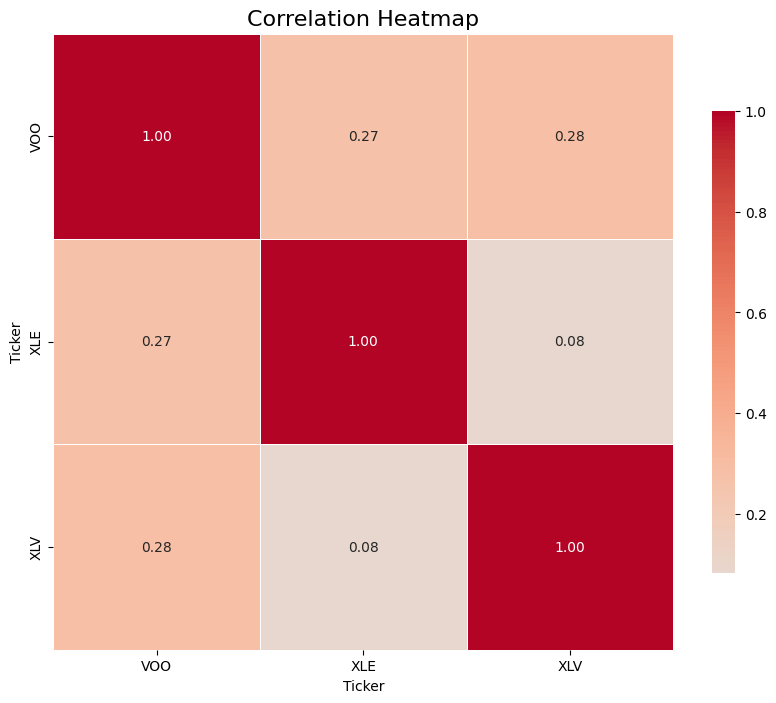

In [32]:

# Example usage
tickers = mrs_1m_df['ETF'].to_list()
ranked_picks = tickers


final_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

# Step 2: Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Format to 2 decimal places
    cmap="coolwarm",    # Color map
    center=0,           # Center the colormap at 0
    linewidths=0.5,     # Lines between cells
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Step 4: Add title and show
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [33]:
final_selection

['XLV', 'XLE', 'VOO']